In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import neurokit2 as nk

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True


SAMPLING_RATE   = 1000   
DURATION        = 10    
RANDOM_SEED     = 42

In [2]:
# ECG Wave Parameters
ti_default = np.array([-70, -15,  0,  15, 100], dtype=float)
ai_default = np.array([1.2,  -5, 30, -7.5, 0.75])
bi_default = np.array([0.25, 0.1, 0.1,  0.1, 0.4])

param_table = pd.DataFrame({
    "Parameter": ["ti", "ai", "bi"],
    "Meaning": [
        "Phase position of each wave along the cardiac cycle",
        "Amplitude of each wave component",
        "Width (duration) of each wave component",
    ],
    "Waves": ["P, Q, R, S, T"] * 3,
})
display(param_table)

,Parameter,Meaning,Waves
0,ti,Phase position of each wave along the cardiac ...,"P, Q, R, S, T"
1,ai,Amplitude of each wave component,"P, Q, R, S, T"
2,bi,Width (duration) of each wave component,"P, Q, R, S, T"


Normal ECG shape: (10000, 12)


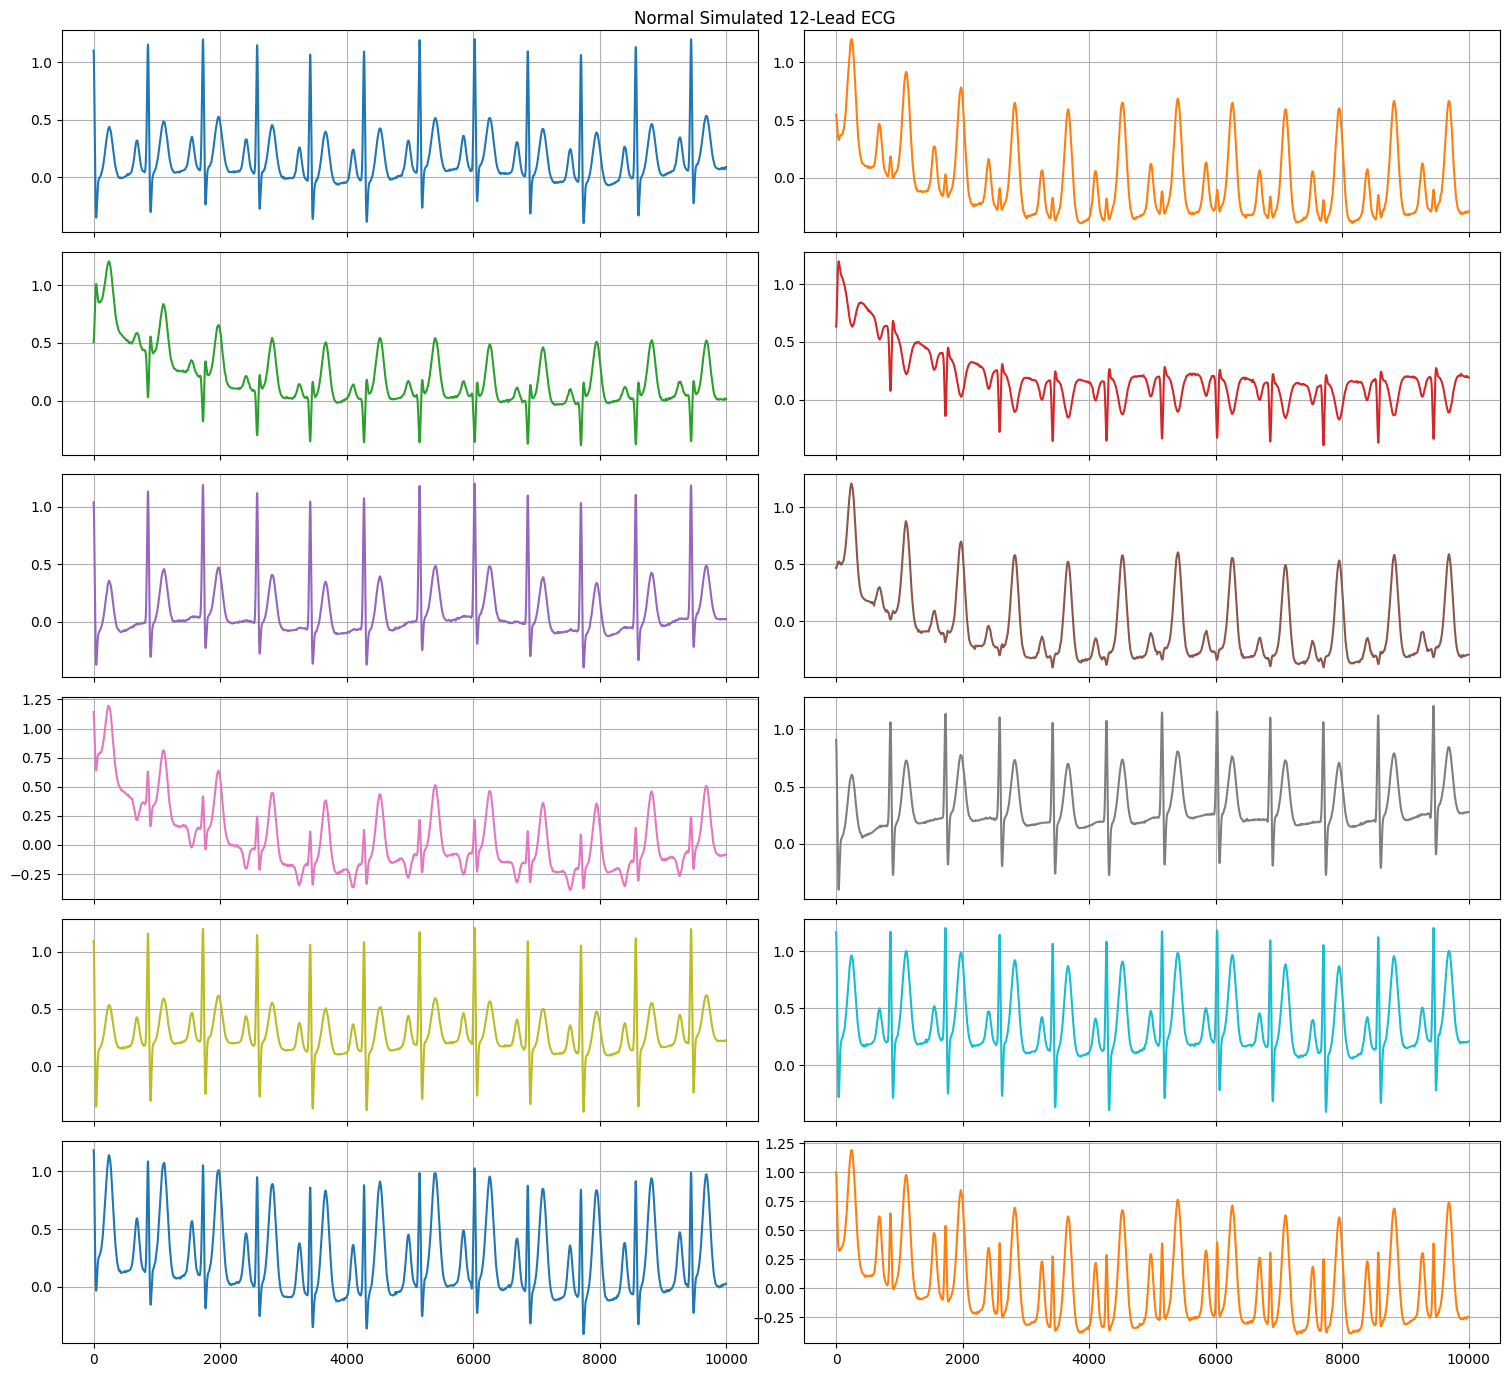

In [3]:
# Simulate a normal 12-lead ECG using the default parameters
ecg12_normal = nk.ecg_simulate(
    duration=DURATION,
    sampling_rate=SAMPLING_RATE,
    method="multileads",
)
print("Normal ECG shape:", ecg12_normal.shape)

ecg12_normal.plot(
    subplots=True, layout=(6, 2),
    figsize=(15, 14), sharex=True, legend=False,
    title="Normal Simulated 12-Lead ECG",
)
plt.tight_layout()
plt.show()

In [4]:
# Build a dataset of 5 normal and 5 abnormal ECGs by perturbing the default parameters
rng = np.random.default_rng(RANDOM_SEED)

ti_abnormal = rng.normal(loc=ti_default, scale=3.0)
ai_abnormal = rng.normal(loc=ai_default, scale=np.abs(ai_default / 5))
bi_abnormal = rng.normal(loc=bi_default, scale=np.abs(bi_default / 5))

comparison = pd.DataFrame(
    {"Normal ti": ti_default, "Abnormal ti": ti_abnormal,
     "Normal ai": ai_default, "Abnormal ai": ai_abnormal,
     "Normal bi": bi_default, "Abnormal bi": bi_abnormal},
    index=["P", "Q", "R", "S", "T"]
).round(3)
display(comparison)

,Normal ti,Abnormal ti,Normal ai,Abnormal ai,Normal bi,Abnormal bi
P,-70.0,-69.086,1.20,0.887,0.25,0.294
Q,-15.0,-18.120,-5.00,-4.872,0.10,0.116
R,0.0,2.251,30.00,28.103,0.10,0.101
S,15.0,17.822,-7.50,-7.525,0.10,0.123
T,100.0,94.147,0.75,0.622,0.40,0.437


Abnormal ECG shape: (10000, 12)


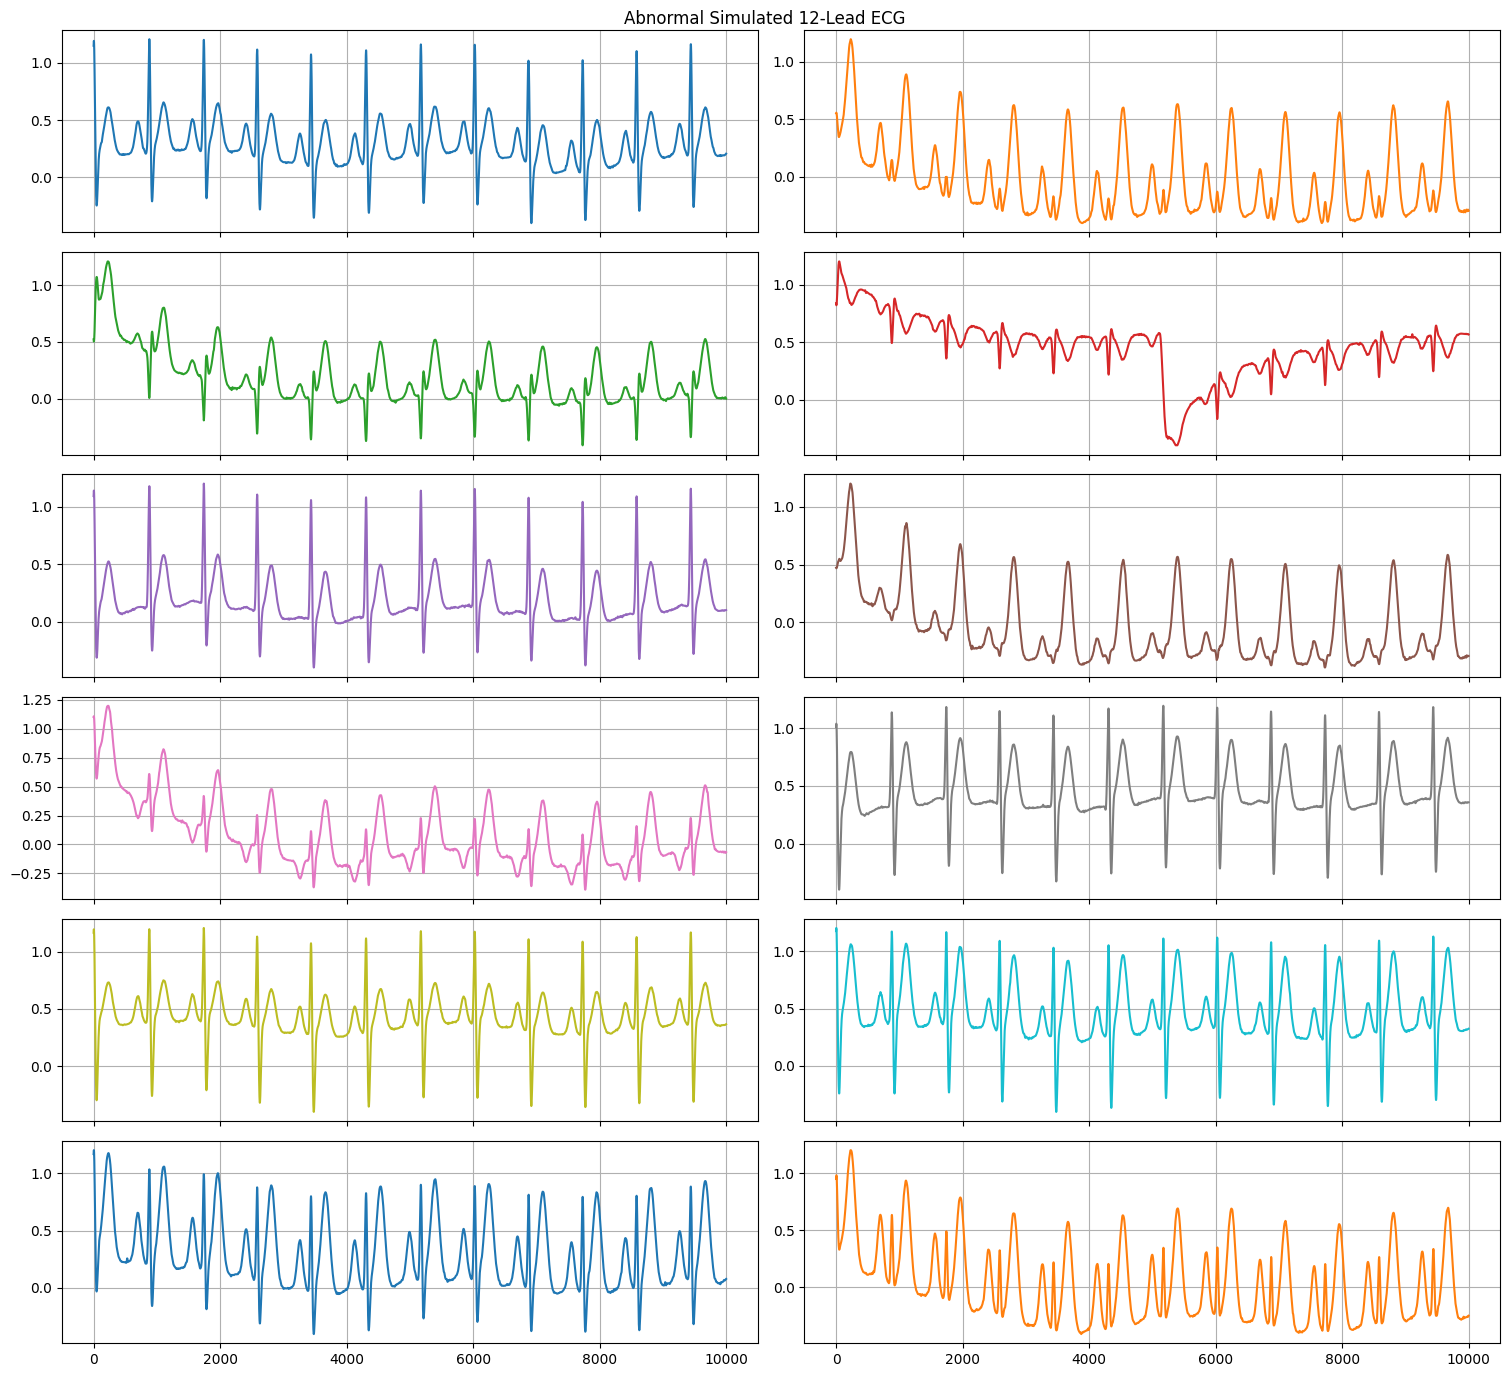

In [5]:
# Simulate an abnormal 12-lead ECG using the perturbed parameters
ecg12_abnormal = nk.ecg_simulate(
    duration=DURATION,
    sampling_rate=SAMPLING_RATE,
    method="multileads",
    ti=ti_abnormal,
    ai=ai_abnormal,
    bi=bi_abnormal,
)
print("Abnormal ECG shape:", ecg12_abnormal.shape)

ecg12_abnormal.plot(
    subplots=True, layout=(6, 2),
    figsize=(15, 14), sharex=True, legend=False,
    title="Abnormal Simulated 12-Lead ECG",
)
plt.tight_layout()
plt.show()

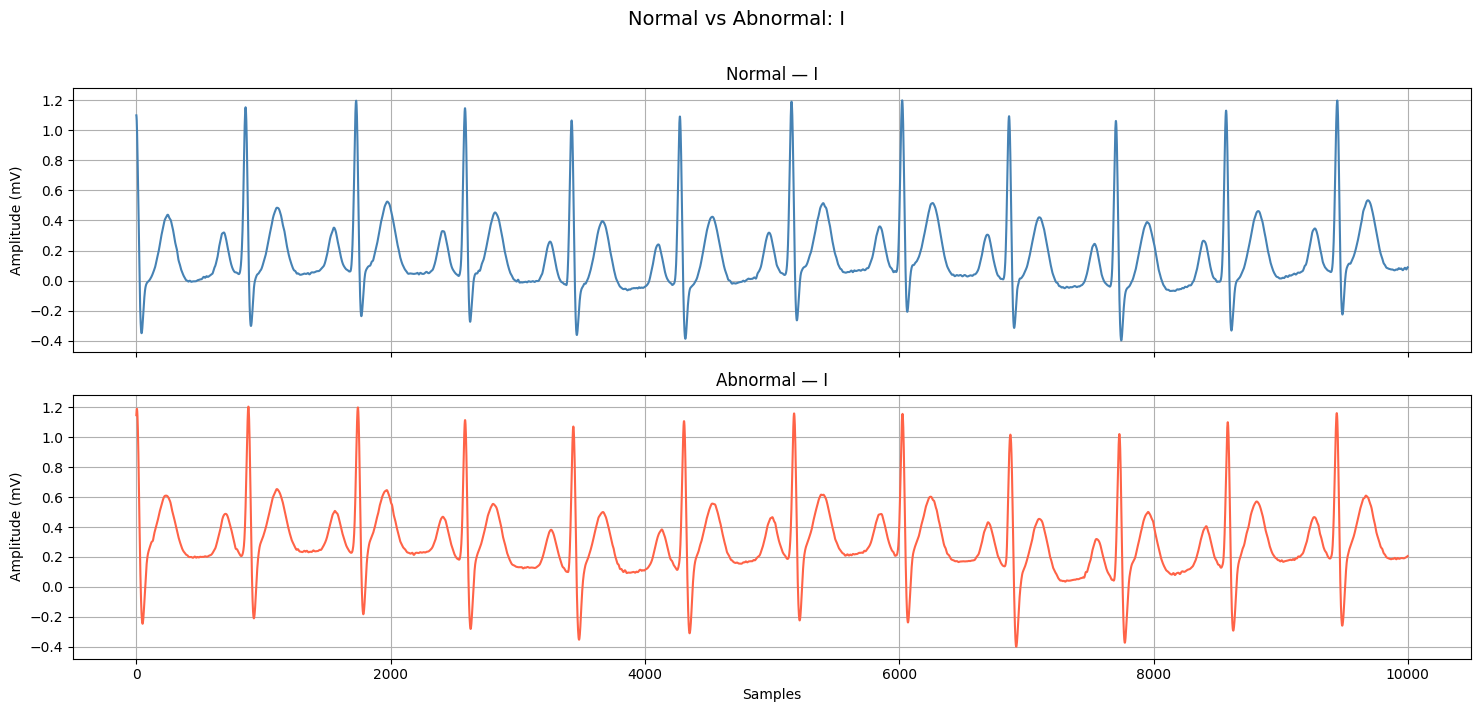

In [6]:
# Side-by-side comparison of Lead I for normal vs abnormal ECGs
lead = ecg12_normal.columns[0]          # Lead I (or whichever is first)

fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True)

axes[0].plot(ecg12_normal[lead].values, color="steelblue")
axes[0].set_title(f"Normal — {lead}")
axes[0].set_ylabel("Amplitude (mV)")

axes[1].plot(ecg12_abnormal[lead].values, color="tomato")
axes[1].set_title(f"Abnormal — {lead}")
axes[1].set_ylabel("Amplitude (mV)")
axes[1].set_xlabel("Samples")

plt.suptitle(f"Normal vs Abnormal: {lead}", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [7]:
# Extract the Lead I signals for further analysis
ecg_normal_1lead   = ecg12_normal[lead].values
ecg_abnormal_1lead = ecg12_abnormal[lead].values

print(f"Working with lead: {lead}")
print(f"Signal length: {len(ecg_normal_1lead)} samples  ({DURATION}s @ {SAMPLING_RATE}Hz)")

Working with lead: I
Signal length: 10000 samples  (10s @ 1000Hz)


Normal   — R-peaks detected: 11
Abnormal — R-peaks detected: 11


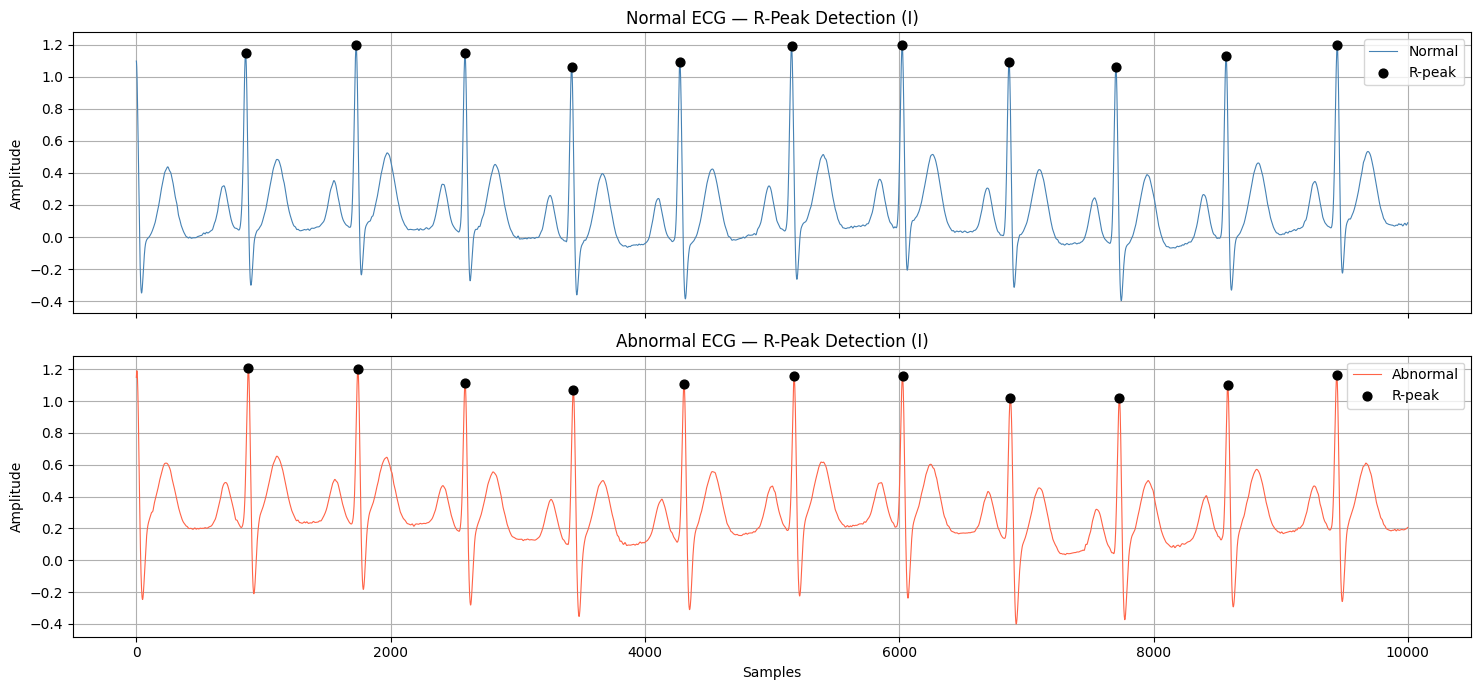

In [8]:
# R-peak detection using NeuroKit2's ecg_peaks function
_, rpeaks_normal   = nk.ecg_peaks(ecg_normal_1lead,   sampling_rate=SAMPLING_RATE)
_, rpeaks_abnormal = nk.ecg_peaks(ecg_abnormal_1lead, sampling_rate=SAMPLING_RATE)

print(f"Normal   — R-peaks detected: {len(rpeaks_normal['ECG_R_Peaks'])}")
print(f"Abnormal — R-peaks detected: {len(rpeaks_abnormal['ECG_R_Peaks'])}")

# Plot R-peaks on both signals
fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True)

for ax, signal, rpeaks, label, color in zip(
    axes,
    [ecg_normal_1lead, ecg_abnormal_1lead],
    [rpeaks_normal, rpeaks_abnormal],
    ["Normal", "Abnormal"],
    ["steelblue", "tomato"],
):
    ax.plot(signal, color=color, lw=0.8, label=label)
    ax.scatter(
        rpeaks["ECG_R_Peaks"], signal[rpeaks["ECG_R_Peaks"]],
        color="black", zorder=5, s=40, label="R-peak"
    )
    ax.set_title(f"{label} ECG — R-Peak Detection ({lead})")
    ax.set_ylabel("Amplitude")
    ax.legend(loc="upper right")

axes[-1].set_xlabel("Samples")
plt.tight_layout()
plt.show()

In [9]:
# PQRST Delineation (Discrete Wavelet Transform)
signals_normal, waves_normal = nk.ecg_delineate(
    ecg_normal_1lead, rpeaks_normal,
    sampling_rate=SAMPLING_RATE, method="dwt",
)

signals_abnormal, waves_abnormal = nk.ecg_delineate(
    ecg_abnormal_1lead, rpeaks_abnormal,
    sampling_rate=SAMPLING_RATE, method="dwt",
)

print("Wave keys:", list(waves_normal.keys()))

Wave keys: ['ECG_P_Peaks', 'ECG_P_Onsets', 'ECG_P_Offsets', 'ECG_Q_Peaks', 'ECG_R_Onsets', 'ECG_R_Offsets', 'ECG_S_Peaks', 'ECG_T_Peaks', 'ECG_T_Onsets', 'ECG_T_Offsets']


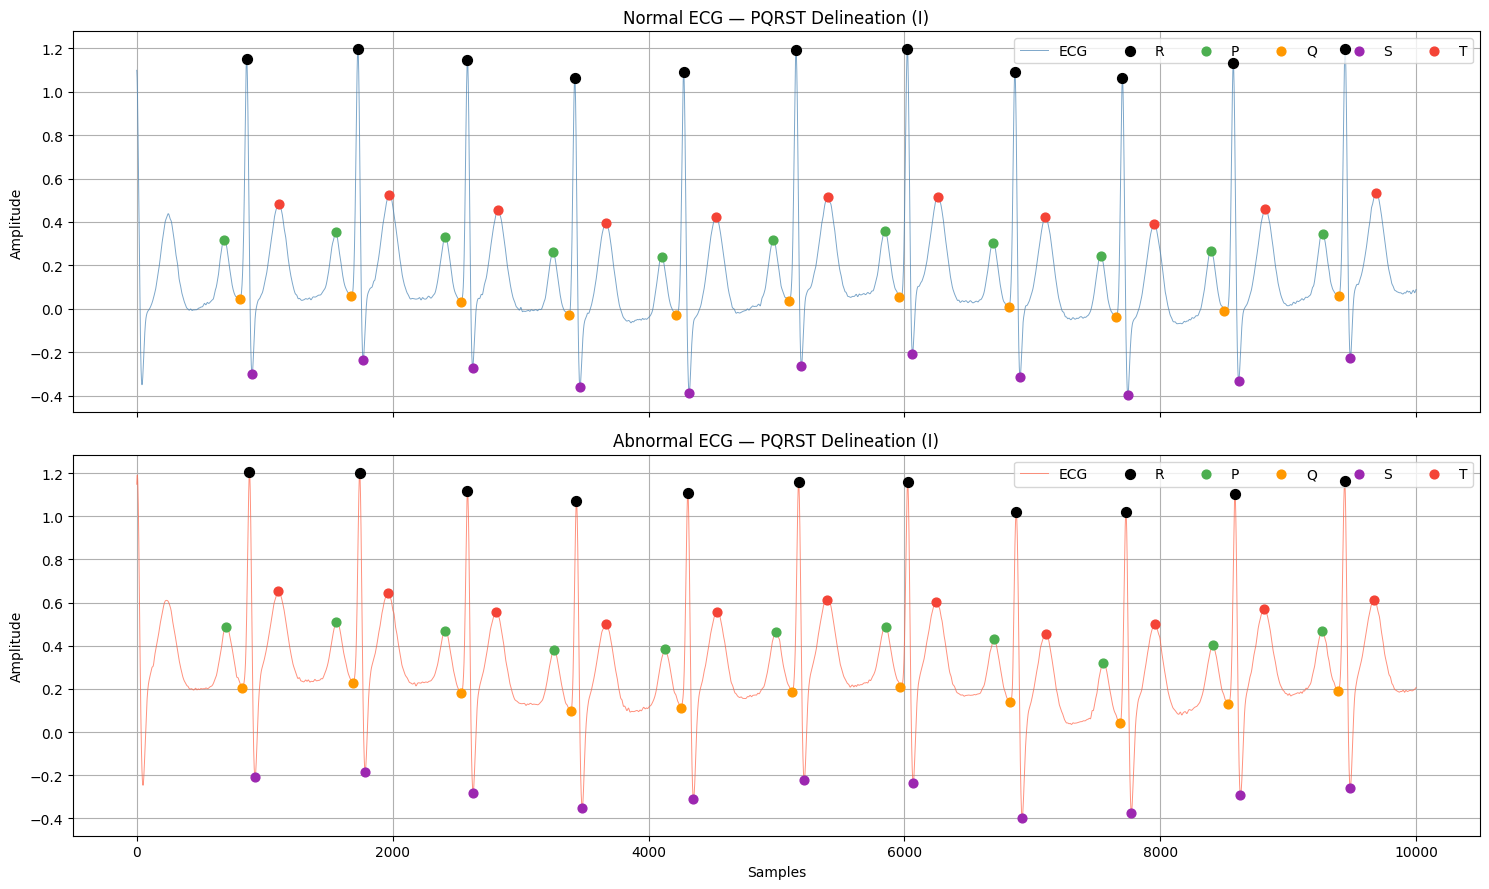

In [10]:
# Visualize the detected P, Q, S, T waves on both signals
wave_colors = {"P": "#4CAF50", "Q": "#FF9800", "S": "#9C27B0", "T": "#F44336"}
wave_keys   = {
    "P": "ECG_P_Peaks",
    "Q": "ECG_Q_Peaks",
    "S": "ECG_S_Peaks",
    "T": "ECG_T_Peaks",
}

fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)

for ax, signal, rpeaks, waves, title, base_color in zip(
    axes,
    [ecg_normal_1lead, ecg_abnormal_1lead],
    [rpeaks_normal, rpeaks_abnormal],
    [waves_normal, waves_abnormal],
    ["Normal ECG", "Abnormal ECG"],
    ["steelblue", "tomato"],
):
    ax.plot(signal, color=base_color, lw=0.7, alpha=0.7, label="ECG")
    ax.scatter(
        rpeaks["ECG_R_Peaks"], signal[rpeaks["ECG_R_Peaks"]],
        color="black", zorder=6, s=50, label="R"
    )
    for wave_name, key in wave_keys.items():
        idxs = [i for i in waves[key] if not np.isnan(i)]
        idxs = np.array(idxs, dtype=int)
        if len(idxs):
            ax.scatter(
                idxs, signal[idxs],
                color=wave_colors[wave_name], zorder=5,
                s=40, label=wave_name
            )
    ax.set_title(f"{title} — PQRST Delineation ({lead})")
    ax.set_ylabel("Amplitude")
    ax.legend(loc="upper right", ncol=6)

axes[-1].set_xlabel("Samples")
plt.tight_layout()
plt.show()

In [11]:
# Wave Statistics: Count, Mean Latency vs R-peak, Std Dev of Latency
def compute_wave_stats(waves, rpeaks, label):
    r = np.array(rpeaks["ECG_R_Peaks"])
    rows = []
    for wave, key in wave_keys.items():
        vals = np.array([v for v in waves[key] if not np.isnan(v)])
        if len(vals) == 0:
            continue
        # Latency from nearest R-peak (ms)
        latencies = []
        for v in vals:
            nearest_r = r[np.argmin(np.abs(r - v))]
            latencies.append((v - nearest_r) / SAMPLING_RATE * 1000)
        rows.append({
            "Signal": label, "Wave": wave,
            "Count": len(vals),
            "Mean latency vs R (ms)": round(np.mean(latencies), 2),
            "Std (ms)": round(np.std(latencies), 2),
        })
    return rows

stats = (
    compute_wave_stats(waves_normal,   rpeaks_normal,   "Normal") +
    compute_wave_stats(waves_abnormal, rpeaks_abnormal, "Abnormal")
)
wave_stats_df = pd.DataFrame(stats)
display(wave_stats_df)

,Signal,Wave,Count,Mean latency vs R (ms),Std (ms)
0,Normal,P,11,-173.73,2.93
1,Normal,Q,11,-54.27,8.11
2,Normal,S,11,41.18,1.03
3,Normal,T,11,244.55,5.31
4,Abnormal,P,11,-175.73,3.16
5,Abnormal,Q,11,-50.73,4.69
6,Abnormal,S,11,43.73,1.05
7,Abnormal,T,11,225.82,3.51


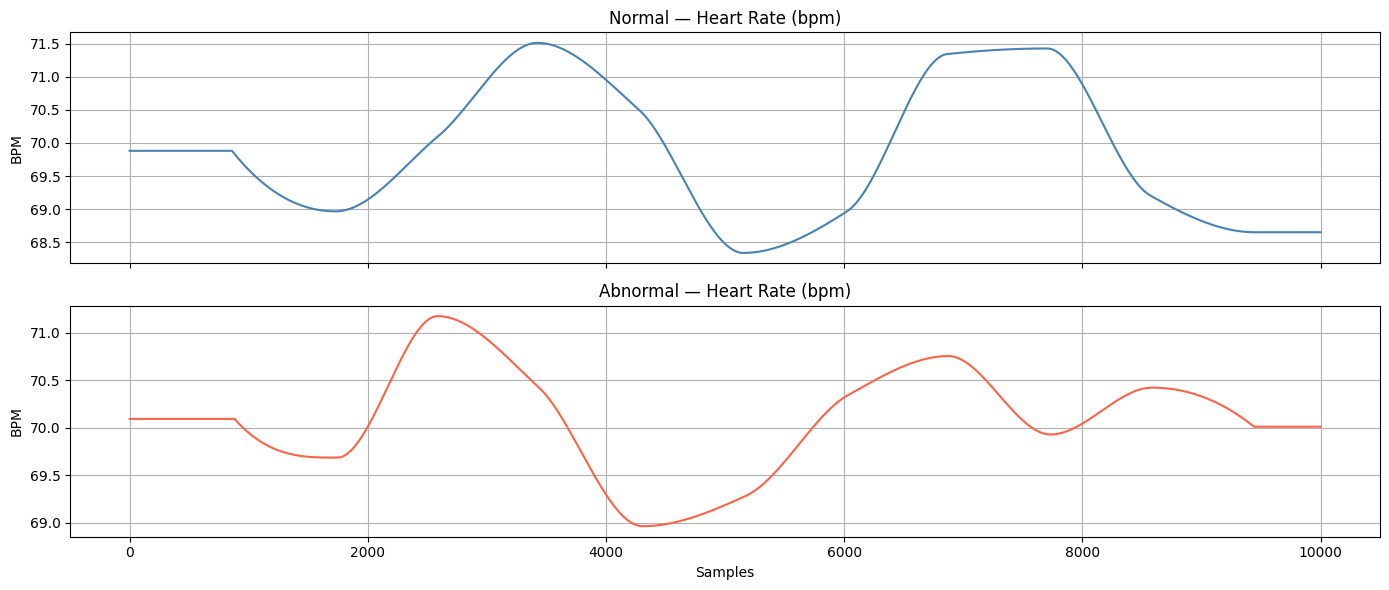

Normal   — mean HR: 69.9 bpm
Abnormal — mean HR: 70.1 bpm


In [12]:
# Instantaneous Heart Rate (HR) estimation from R-peaks
ecg_rate_normal = nk.ecg_rate(
    rpeaks_normal,
    sampling_rate=SAMPLING_RATE,
    desired_length=len(ecg_normal_1lead),
)

ecg_rate_abnormal = nk.ecg_rate(
    rpeaks_abnormal,
    sampling_rate=SAMPLING_RATE,
    desired_length=len(ecg_abnormal_1lead),
)

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(ecg_rate_normal,   color="steelblue"); axes[0].set_title("Normal — Heart Rate (bpm)")
axes[1].plot(ecg_rate_abnormal, color="tomato");   axes[1].set_title("Abnormal — Heart Rate (bpm)")
for ax in axes:
    ax.set_ylabel("BPM")
axes[-1].set_xlabel("Samples")
plt.tight_layout()
plt.show()

print(f"Normal   — mean HR: {ecg_rate_normal.mean():.1f} bpm")
print(f"Abnormal — mean HR: {ecg_rate_abnormal.mean():.1f} bpm")

In [13]:
# EDR with Four Methods
EDR_METHODS = {
    "Van Gent et al. (default)" : {},
    "Charlton et al. 2016"      : {"method": "charlton2016"},
    "Soni et al. 2019"          : {"method": "soni2019"},
    "Sarkar et al. 2015"        : {"method": "sarkar2015"},
}

def compute_edr(ecg_rate, methods):
    return pd.DataFrame({
        name: nk.ecg_rsp(ecg_rate, sampling_rate=SAMPLING_RATE, **kwargs)
        for name, kwargs in methods.items()
    })

edr_normal   = compute_edr(ecg_rate_normal,   EDR_METHODS)
edr_abnormal = compute_edr(ecg_rate_abnormal, EDR_METHODS)

print("EDR computed for both signals.")
display(edr_normal.describe().round(4))

EDR computed for both signals.


,Van Gent et al. (default),Charlton et al. 2016,Soni et al. 2019,Sarkar et al. 2015
count,10000.0000,10000.0000,10000.0000,10000.0000
mean,-0.0203,0.0003,69.8986,-0.0041
std,0.8994,0.9224,0.9674,0.8663
min,-1.9766,-1.8598,68.2918,-1.6807
25%,-0.5749,-0.5746,69.0682,-0.5573
50%,-0.0123,-0.0005,69.7450,-0.0530
75%,0.7061,0.8090,70.7717,0.6361
max,1.3752,1.6254,71.6206,1.7345


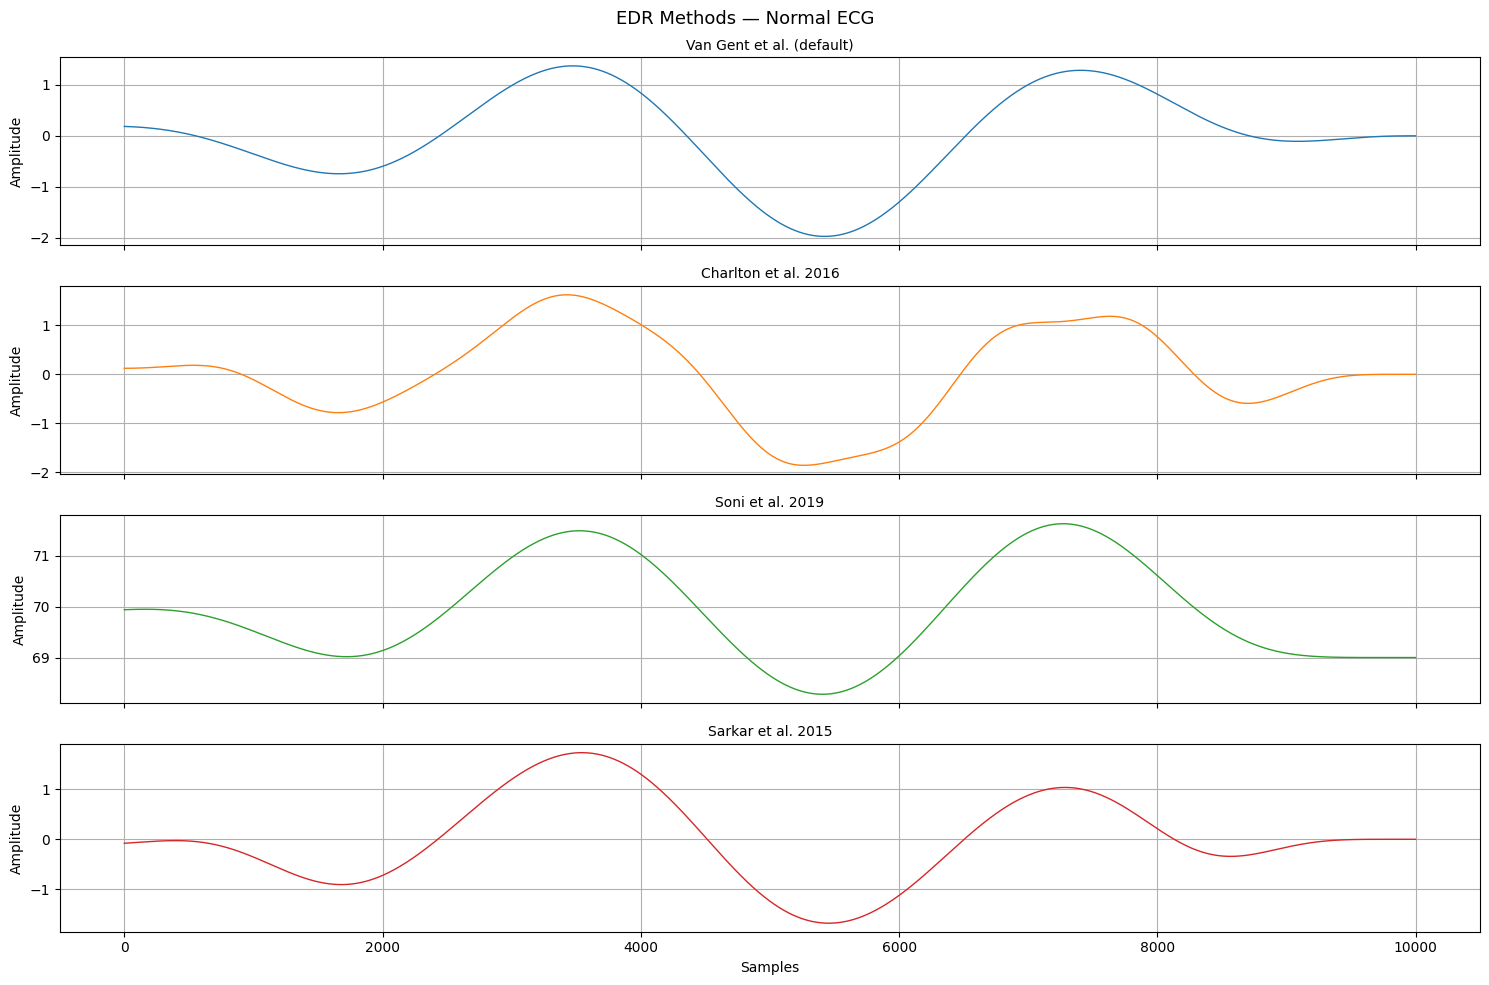

In [14]:
# Plot the normal EDR signals for all methods side-by-side
method_colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

fig, axes = plt.subplots(len(EDR_METHODS), 1, figsize=(15, 10), sharex=True)
fig.suptitle("EDR Methods — Normal ECG", fontsize=13)
for ax, (name, series), color in zip(axes, edr_normal.items(), method_colors):
    ax.plot(series.values, color=color, lw=1)
    ax.set_title(name, fontsize=10)
    ax.set_ylabel("Amplitude")
axes[-1].set_xlabel("Samples")
plt.tight_layout()
plt.show()

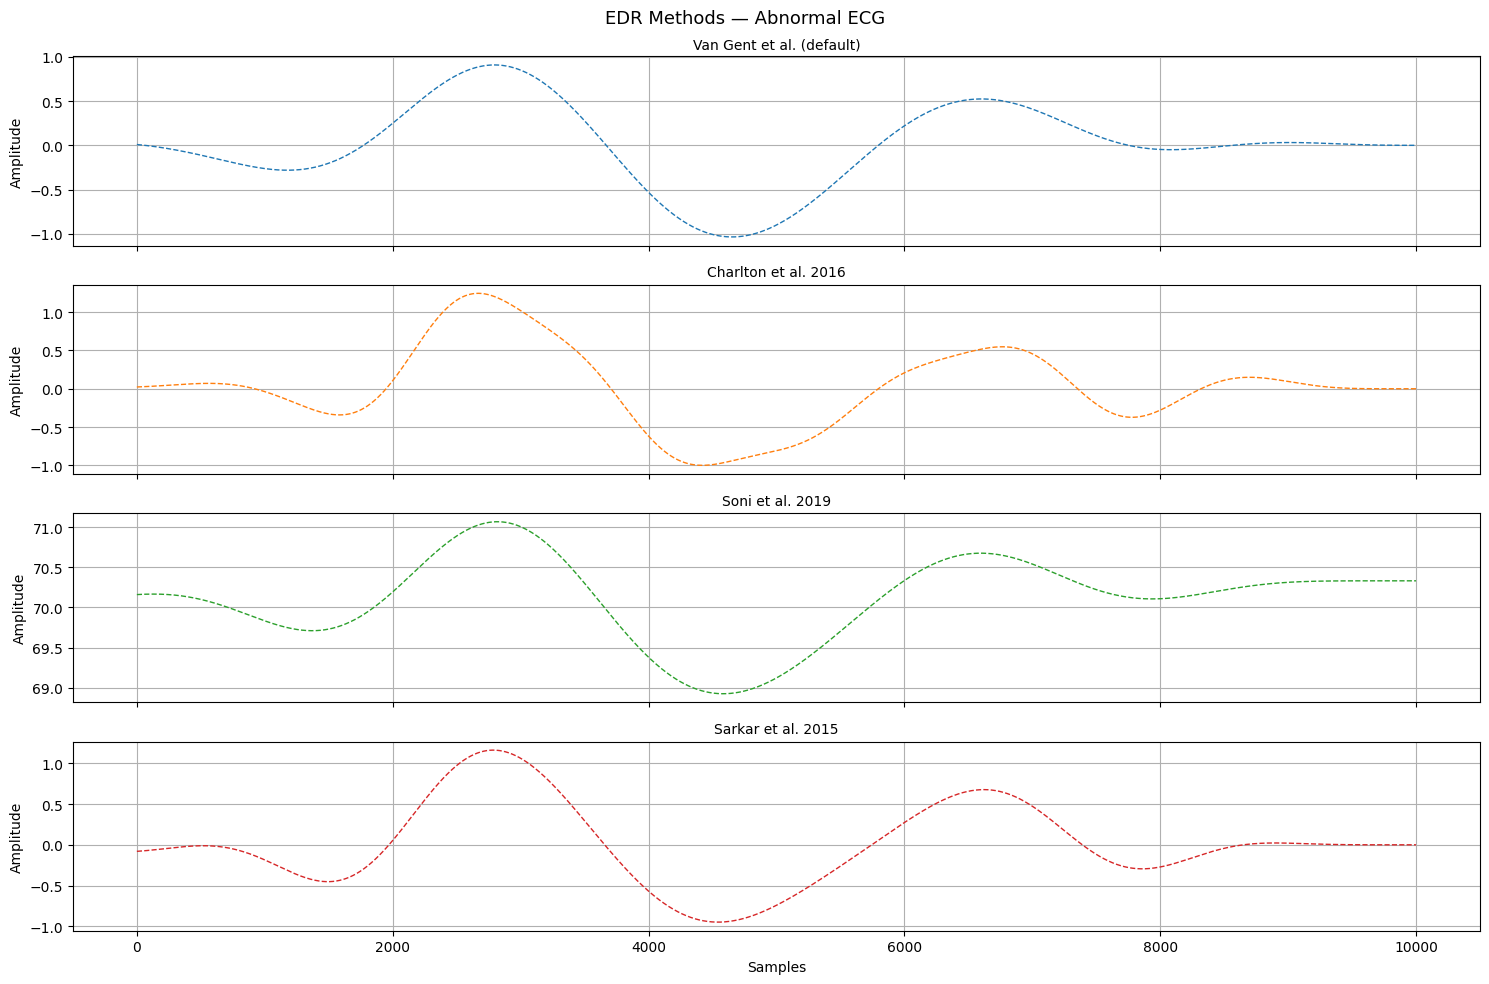

In [15]:
# Plot the abnormal EDR signals for all methods side-by-side
fig, axes = plt.subplots(len(EDR_METHODS), 1, figsize=(15, 10), sharex=True)
fig.suptitle("EDR Methods — Abnormal ECG", fontsize=13)
for ax, (name, series), color in zip(axes, edr_abnormal.items(), method_colors):
    ax.plot(series.values, color=color, lw=1, linestyle="--")
    ax.set_title(name, fontsize=10)
    ax.set_ylabel("Amplitude")
axes[-1].set_xlabel("Samples")
plt.tight_layout()
plt.show()

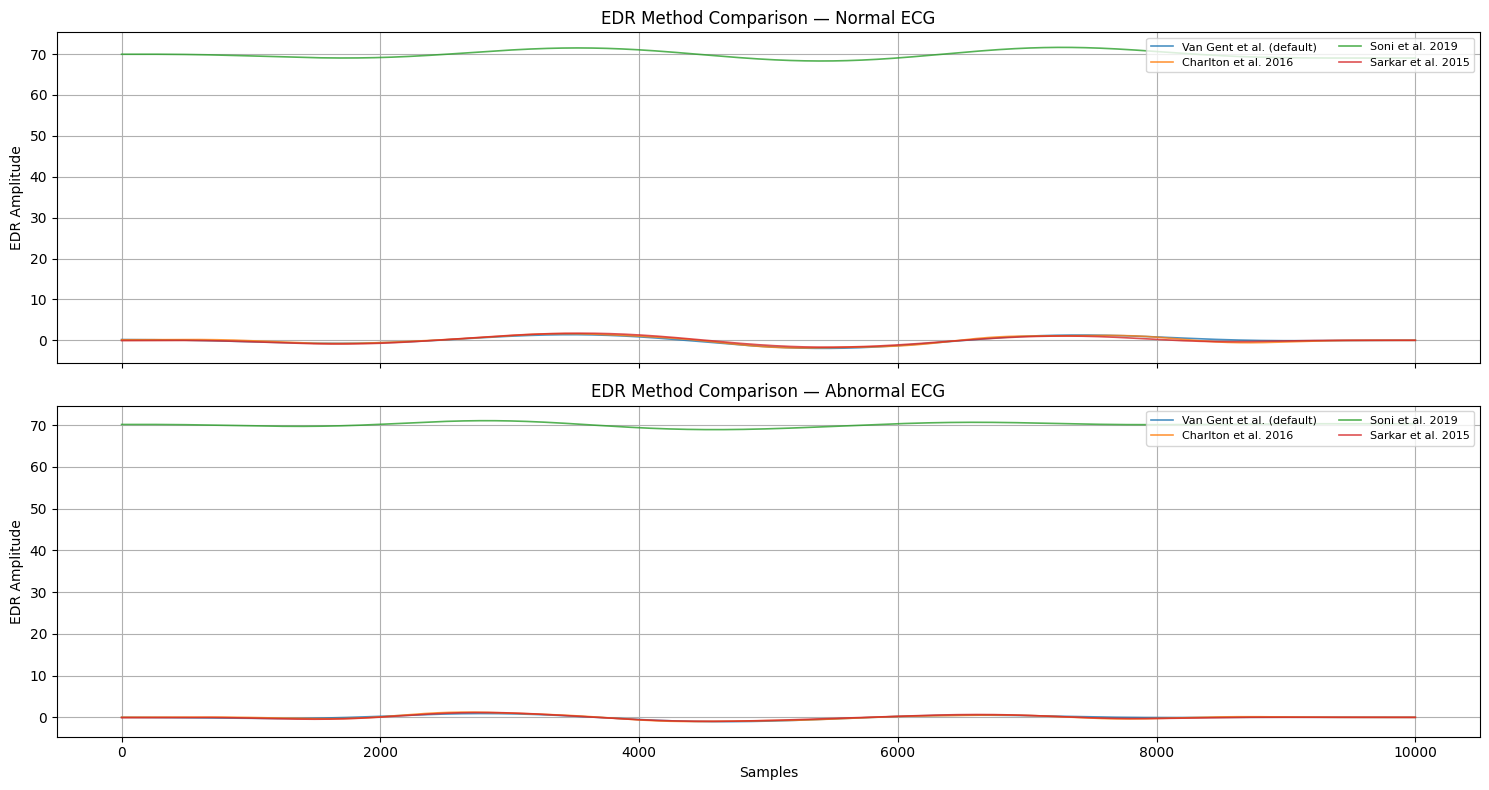

In [16]:
# Overlaid comparison of all EDR methods for normal vs abnormal signals
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

for ax, edr_df, title in zip(
    axes,
    [edr_normal, edr_abnormal],
    ["Normal ECG", "Abnormal ECG"],
):
    for (name, series), color in zip(edr_df.items(), method_colors):
        ax.plot(series.values, label=name, color=color, alpha=0.8, lw=1.2)
    ax.set_title(f"EDR Method Comparison — {title}")
    ax.set_ylabel("EDR Amplitude")
    ax.legend(fontsize=8, loc="upper right", ncol=2)

axes[-1].set_xlabel("Samples")
plt.tight_layout()
plt.show()

In [17]:
# EDR Summary Statistics (mean, std) for normal vs abnormal signals
summary_normal   = edr_normal.describe().T.add_suffix("_normal")
summary_abnormal = edr_abnormal.describe().T.add_suffix("_abnormal")

edr_summary = pd.concat([summary_normal, summary_abnormal], axis=1)
print("\nEDR Summary Statistics (Normal vs Abnormal):")
display(edr_summary[["mean_normal", "std_normal", "mean_abnormal", "std_abnormal"]].round(4))


EDR Summary Statistics (Normal vs Abnormal):


,mean_normal,std_normal,mean_abnormal,std_abnormal
Van Gent et al. (default),-0.0203,0.8994,0.0014,0.4670
Charlton et al. 2016,0.0003,0.9224,0.0228,0.5216
Soni et al. 2019,69.8986,0.9674,70.1085,0.5207
Sarkar et al. 2015,-0.0041,0.8663,0.0086,0.5030


In [18]:
# Final Summary of Pipeline Results
divider = "─" * 60

for label, rpeaks, waves, ecg_rate, edr_df in [
    ("NORMAL",   rpeaks_normal,   waves_normal,   ecg_rate_normal,   edr_normal),
    ("ABNORMAL", rpeaks_abnormal, waves_abnormal, ecg_rate_abnormal, edr_abnormal),
]:
    print(divider)
    print(f"  {label} ECG — Pipeline Summary")
    print(f"  R-peaks detected  : {len(rpeaks['ECG_R_Peaks'])}")
    print(f"  Mean heart rate   : {ecg_rate.mean():.1f} bpm")
    for wave, key in wave_keys.items():
        count = sum(1 for v in waves[key] if not np.isnan(v))
        print(f"  {wave}-peaks detected   : {count}")
    print("  EDR methods run   :", ", ".join(EDR_METHODS.keys()))
    print()

print("  Pipeline complete!")

────────────────────────────────────────────────────────────
  NORMAL ECG — Pipeline Summary
  R-peaks detected  : 11
  Mean heart rate   : 69.9 bpm
  P-peaks detected   : 11
  Q-peaks detected   : 11
  S-peaks detected   : 11
  T-peaks detected   : 11
  EDR methods run   : Van Gent et al. (default), Charlton et al. 2016, Soni et al. 2019, Sarkar et al. 2015

────────────────────────────────────────────────────────────
  ABNORMAL ECG — Pipeline Summary
  R-peaks detected  : 11
  Mean heart rate   : 70.1 bpm
  P-peaks detected   : 11
  Q-peaks detected   : 11
  S-peaks detected   : 11
  T-peaks detected   : 11
  EDR methods run   : Van Gent et al. (default), Charlton et al. 2016, Soni et al. 2019, Sarkar et al. 2015

  Pipeline complete!
